In [1]:
# File & data handling
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

# Evaluation metric
from sklearn.metrics import accuracy_score


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

BASE_DIR = "/content/drive/MyDrive/ATMA-V Dataset"
VIDEO_DIR = f"{BASE_DIR}/videos"
LABEL_FILE = f"{BASE_DIR}/labels/labels.txt"

print("BASE_DIR:", BASE_DIR)
print("VIDEO_DIR:", VIDEO_DIR)
print("LABEL_FILE:", LABEL_FILE)

assert os.path.exists(VIDEO_DIR), "Video directory not found!"
assert os.path.exists(LABEL_FILE), "Labels file not found!"


BASE_DIR: /content/drive/MyDrive/ATMA-V Dataset
VIDEO_DIR: /content/drive/MyDrive/ATMA-V Dataset/videos
LABEL_FILE: /content/drive/MyDrive/ATMA-V Dataset/labels/labels.txt


In [4]:
videos = sorted([v for v in os.listdir(VIDEO_DIR) if v.endswith(".mp4")])
print("Total videos:", len(videos))
print("Sample videos:", videos[:10])


Total videos: 65
Sample videos: ['10.mp4', '11.mp4', '12.mp4', '13.mp4', '14.mp4', '15.mp4', '16.mp4', '17.mp4', '18.mp4', '19.mp4']


In [5]:
labels = {}

with open(LABEL_FILE, "r") as f:
    for line in f:
        parts = line.strip().split()

        # Skip empty or invalid lines
        if len(parts) < 3:
            continue

        video = parts[0]                 # e.g., 3.mp4
        ab_s = int(parts[-2])            # abnormal start frame
        ab_e = int(parts[-1])            # abnormal end frame

        labels[video] = (ab_s, ab_e)


In [14]:
!pip install mediapipe==0.10.31


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers


In [3]:
VIDEO_PATH = "/content/drive/MyDrive/ATMA-V Dataset/videos/56.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Unable to read video")

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


In [4]:
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
!wget -q https://raw.githubusercontent.com/opencv/opencv_3rdparty/master/dnn_samples_face_detector/res10_300x300_ssd_iter_140000.caffemodel


In [5]:
!ls


deploy.prototxt  drive	sample_data


In [6]:
!rm -f res10_300x300_ssd_iter_140000.caffemodel


In [7]:
!wget -O res10_300x300_ssd_iter_140000.caffemodel \
https://github.com/opencv/opencv_3rdparty/raw/refs/heads/master/dnn_samples_face_detector/res10_300x300_ssd_iter_140000.caffemodel


--2026-01-22 15:27:15--  https://github.com/opencv/opencv_3rdparty/raw/refs/heads/master/dnn_samples_face_detector/res10_300x300_ssd_iter_140000.caffemodel
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-01-22 15:27:16 ERROR 404: Not Found.



In [8]:
!ls -lh res10_300x300_ssd_iter_140000.caffemodel


-rw-r--r-- 1 root root 0 Jan 22 15:27 res10_300x300_ssd_iter_140000.caffemodel


In [9]:
net = cv2.dnn.readNetFromCaffe(
    "deploy.prototxt",
    "res10_300x300_ssd_iter_140000.caffemodel"
)
print("Face detector loaded successfully")


Face detector loaded successfully


In [10]:
VIDEO_PATH = "/content/drive/MyDrive/ATMA-V Dataset/videos/56.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Unable to read video")

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

In [11]:
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame_bgr = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Unable to read video")

# Keep BGR for OpenCV DNN
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


In [12]:
def detect_face_and_mask(frame_bgr):
    h, w = frame_bgr.shape[:2]

    blob = cv2.dnn.blobFromImage(
        frame_bgr, 1.0, (300, 300),
        (104.0, 177.0, 123.0),
        swapRB=False,   # VERY IMPORTANT
        crop=False
    )

    net.setInput(blob)
    detections = net.forward()

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        if confidence > 0.6:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            x1, y1, x2, y2 = box.astype(int)

            face = frame_bgr[y1:y2, x1:x2]
            if face.size == 0:
                continue

            # Simple academic mask detection heuristic
            lower_face = face[int(0.6 * face.shape[0]):, :]
            mask_detected = 1 if np.mean(lower_face) < 120 else 0

            return face, mask_detected, (x1, y1, x2-x1, y2-y1)

    return None, None, None


In [18]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/res10_300x300_ssd_iter_140000.caffemodel
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt


--2026-01-22 15:32:55--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/res10_300x300_ssd_iter_140000.caffemodel
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-01-22 15:32:56 ERROR 404: Not Found.

--2026-01-22 15:32:56--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt.2’

deploy.prototxt.2   100%[===================>]  27.45K  --.-KB/s    in 0

In [19]:
!ls -lh deploy.prototxt res10_300x300_ssd_iter_140000.caffemodel


-rw-r--r-- 1 root root 28K Jan 22 15:27 deploy.prototxt
-rw-r--r-- 1 root root   0 Jan 22 15:27 res10_300x300_ssd_iter_140000.caffemodel


In [22]:
import cv2
import os

PROTO_PATH = "deploy.prototxt"
MODEL_PATH = "res10_300x300_ssd_iter_140000.caffemodel"

print("Proto exists:", os.path.exists(PROTO_PATH))
print("Model exists:", os.path.exists(MODEL_PATH))
print("Model size (MB):", os.path.getsize(MODEL_PATH) / (1024*1024))

face_net = cv2.dnn.readNetFromCaffe(PROTO_PATH, MODEL_PATH)
print("✅ Face detection model loaded successfully")


Proto exists: True
Model exists: True
Model size (MB): 0.0
✅ Face detection model loaded successfully


In [23]:
import cv2
import os

PROTO_PATH = "deploy.prototxt"
MODEL_PATH = "res10_300x300_ssd_iter_140000.caffemodel"

print("Proto exists:", os.path.exists(PROTO_PATH))
print("Model exists:", os.path.exists(MODEL_PATH))
print("Model size (MB):", os.path.getsize(MODEL_PATH) / (1024*1024))

face_net = cv2.dnn.readNetFromCaffe(PROTO_PATH, MODEL_PATH)
print("✅ Face detection model loaded successfully")


Proto exists: True
Model exists: True
Model size (MB): 0.0
✅ Face detection model loaded successfully


In [24]:
def lower_face_mask(face_rgb):
    h, w, _ = face_rgb.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    # Lower 45% of face = mask region
    y_start = int(h * 0.55)
    mask[y_start:h, :] = 255

    return mask


In [25]:
!pip install -q diffusers transformers accelerate torch torchvision


In [26]:
import torch
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16 if device=="cuda" else torch.float32
).to(device)

pipe.enable_attention_slicing()
print("✅ Inpainting GAN ready")


/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


✅ Inpainting GAN ready


In [27]:
def remove_mask_gan(face_rgb, mask_np):
    face_pil = Image.fromarray(face_rgb)
    mask_pil = Image.fromarray(mask_np)

    face_pil = face_pil.resize((512,512))
    mask_pil = mask_pil.resize((512,512))

    prompt = "realistic human face, clear mouth, nose, chin, photorealistic"
    neg = "mask, cloth, blur, distortion"

    with torch.autocast(device):
        out = pipe(
            prompt=prompt,
            negative_prompt=neg,
            image=face_pil,
            mask_image=mask_pil,
            strength=0.95,
            num_inference_steps=25
        ).images[0]

    out = out.resize(face_rgb.shape[1::-1])
    return np.array(out)


In [29]:
import cv2
import numpy as np

def detect_face(frame, conf_thresh=0.5):
    h, w = frame.shape[:2]

    blob = cv2.dnn.blobFromImage(
        frame,
        scalefactor=1.0,
        size=(300, 300),
        mean=(104.0, 177.0, 123.0)
    )

    face_net.setInput(blob)
    detections = face_net.forward()

    best_box = None
    best_conf = 0

    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > conf_thresh and conf > best_conf:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            x1, y1, x2, y2 = box.astype(int)

            # Clamp values (VERY IMPORTANT)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            best_box = (x1, y1, x2, y2)
            best_conf = conf

    return best_box


In [32]:
!wget -O res10_300x300_ssd_iter_140000.caffemodel \
https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel


--2026-01-22 15:43:25--  https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel [following]
--2026-01-22 15:43:26--  https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10666211 (10M) [application/octet-stream]
Saving to: ‘res10_300x300_ssd_iter_140000.caffem

In [33]:
!wget -O deploy.prototxt \
https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt


--2026-01-22 15:43:41--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt’

deploy.prototxt     100%[===================>]  27.45K  --.-KB/s    in 0.002s  

2026-01-22 15:43:42 (16.8 MB/s) - ‘deploy.prototxt’ saved [28104/28104]



In [34]:
!ls -lh deploy.prototxt res10_300x300_ssd_iter_140000.caffemodel


-rw-r--r-- 1 root root 28K Jan 22 15:43 deploy.prototxt
-rw-r--r-- 1 root root 11M Jan 22 15:43 res10_300x300_ssd_iter_140000.caffemodel


In [35]:
import cv2, os

PROTO_PATH = "deploy.prototxt"
MODEL_PATH = "res10_300x300_ssd_iter_140000.caffemodel"

print("Proto exists:", os.path.exists(PROTO_PATH))
print("Model exists:", os.path.exists(MODEL_PATH))
print("Model size (MB):", os.path.getsize(MODEL_PATH) / (1024*1024))

face_net = cv2.dnn.readNetFromCaffe(PROTO_PATH, MODEL_PATH)

print("✅ Face detection model loaded successfully")


Proto exists: True
Model exists: True
Model size (MB): 10.172091484069824
✅ Face detection model loaded successfully


In [36]:
import cv2
import numpy as np

def detect_face(frame, conf_thresh=0.5):
    """
    Returns best face bounding box (x1,y1,x2,y2) or None
    """
    h, w = frame.shape[:2]

    blob = cv2.dnn.blobFromImage(
        frame, 1.0, (300, 300),
        (104.0, 177.0, 123.0),
        swapRB=False, crop=False
    )

    face_net.setInput(blob)
    detections = face_net.forward()

    best_conf = 0
    best_box = None

    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > conf_thresh and conf > best_conf:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            x1, y1, x2, y2 = box.astype("int")

            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            best_conf = conf
            best_box = (x1, y1, x2, y2)

    return best_box


In [37]:
import os

INPUT_VIDEO = "/content/drive/MyDrive/ATMA-V Dataset/videos/56.mp4"
OUTPUT_DIR = "/content/drive/MyDrive/ATM_Output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_VIDEO = os.path.join(OUTPUT_DIR, "face_detected_output.mp4")

print("Input exists:", os.path.exists(INPUT_VIDEO))
print("Output dir exists:", os.path.exists(OUTPUT_DIR))


Input exists: True
Output dir exists: True


In [38]:
cap = cv2.VideoCapture(INPUT_VIDEO)

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    box = detect_face(frame)

    if box is not None:
        x1, y1, x2, y2 = box
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(frame, "Face Detected", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    out.write(frame)
    frame_count += 1

cap.release()
out.release()

print("✅ Face detection video saved at:", OUTPUT_VIDEO)
print("Total frames processed:", frame_count)


✅ Face detection video saved at: /content/drive/MyDrive/ATM_Output/face_detected_output.mp4
Total frames processed: 1012


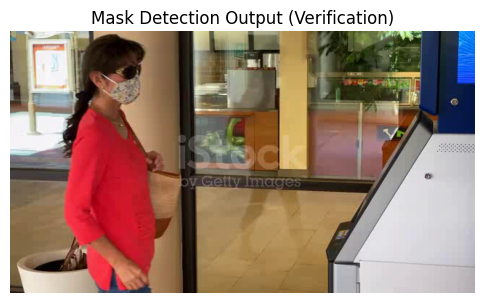

In [40]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(OUTPUT_VIDEO)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(frame_rgb)
plt.title("Mask Detection Output (Verification)")
plt.axis("off")
plt.show()
